<h1>Netflix Recommendation System</h1>

The datasets we're using is from [movielens](https://movielens.org/). The datasets are available from https://grouplens.org/datasets/movielens/latest/

We'll be using the small version

<h2>Problem Statement</h2>
<p>Building a hybrid movie recommendation system combining collaborative filtering (user behavior) and content-based filtering (movie metadata like genres & tags).</p>

<h3>1.Importing Libraries</h3>

In [34]:
!pip install seaborn
!pip install matplotlib

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached matplotlib-3.10.8-cp313-cp313-macosx_11_0_arm64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp313-cp313-macosx_10_13_universal2.whl.metadata (117 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-macosx_11_0_arm64.whl.metadata (5.1 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached matplotlib-3.10.8-cp313-cp313-macosx_11_0_arm64.whl (8.1 MB)
Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl (274 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.62.1-cp313-cp313-macosx_10_13_universal2.whl (2.9 MB)
Using cached kiwisolver-1.5.0-cp313-cp313-macosx_11_0_arm64.whl (64 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 7.4 M

In [36]:
import string
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns


import warnings
warnings.filterwarnings("ignore")

<h3>2.Loading Dataset</h3>

In [38]:
movies = pd.read_csv("movies.csv")
ratings = pd.read_csv("ratings.csv")
tags = pd.read_csv("tags.csv")
links = pd.read_csv("links.csv")


<h3>3.EDA</h3>

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [22]:
tags.head()

,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200


In [23]:
movies.info()

<class 'pandas.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   movieId  9742 non-null   int64
 1   title    9742 non-null   str  
 2   genres   9742 non-null   str  
dtypes: int64(1), str(2)
memory usage: 228.5 KB


In [24]:
ratings.info()

<class 'pandas.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


In [25]:
tags.info()

<class 'pandas.DataFrame'>
RangeIndex: 3683 entries, 0 to 3682
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   userId     3683 non-null   int64
 1   movieId    3683 non-null   int64
 2   tag        3683 non-null   str  
 3   timestamp  3683 non-null   int64
dtypes: int64(3), str(1)
memory usage: 115.2 KB


There's no null values in all the datasets

In [28]:
print("Number of unique movies:", movies['movieId'].nunique())
print("Number of unique users:", ratings['userId'].nunique())
print("Number of unique tags:", tags['tag'].nunique())
print("Total ratings:", len(ratings))

Number of unique movies: 9742
Number of unique users: 610
Number of unique tags: 1589
Total ratings: 100836


In [29]:
#Checking sparsity
print("No. of users:", ratings['userId'].nunique())
print("No. of movies:", ratings['movieId'].nunique())
print("Total ratings:", len(ratings))

No. of users: 610
No. of movies: 9724
Total ratings: 100836


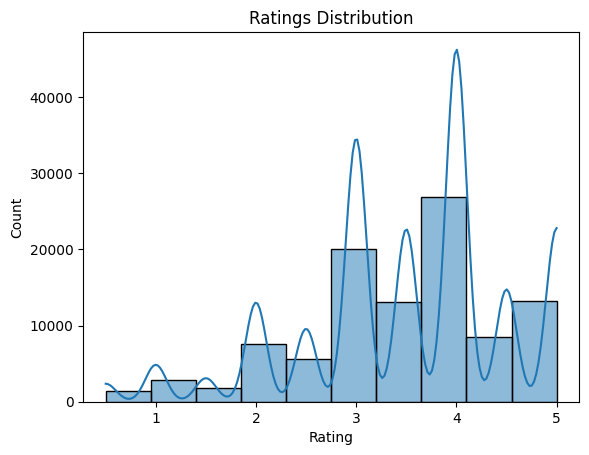

In [37]:
#Ratings distribution
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(ratings['rating'], bins=10, kde=True)

plt.title("Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.show()

In [40]:
#Most rated movies
ratings.groupby('movieId')['rating'].count().sort_values(ascending=False).head(10)

movieId
356     329
318     317
296     307
593     279
2571    278
260     251
480     238
110     237
589     224
527     220
Name: rating, dtype: int64

<h3>4. Data Cleaning & Preprocessing</h3>

In [41]:
#Merge datasets
df = ratings.merge(movies, on='movieId')
df = df.merge(tags, on=['movieId', 'userId'], how='left')
df.head()

,userId,movieId,rating,timestamp_x,title,genres,tag,timestamp_y
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,NaN,NaN
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance,NaN,NaN
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller,NaN,NaN
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,NaN,NaN
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,NaN,NaN


In [42]:
#Handle missing tags
df['tag'] = df['tag'].fillna('')
df['timestamp_y'] = df['timestamp_y'].fillna(0)

In [44]:
#Check
df.head()

,userId,movieId,rating,timestamp_x,title,genres,tag,timestamp_y
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,,0.0
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance,,0.0
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller,,0.0
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,,0.0
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,,0.0


In [45]:
#Clean genres
df['genres'] = df['genres'].str.replace('|', ' ')

In [48]:
#Extracting year from title
df['year'] = df['title'].str.extract(r'\((\d{4})\)')
df.head()

,userId,movieId,rating,timestamp_x,title,genres,tag,timestamp_y,year
0,1,1,4.0,964982703,Toy Story (1995),Adventure Animation Children Comedy Fantasy,,0.0,1995
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy Romance,,0.0,1995
2,1,6,4.0,964982224,Heat (1995),Action Crime Thriller,,0.0,1995
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery Thriller,,0.0,1995
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime Mystery Thriller,,0.0,1995


### 5. Feature Engineering

In [53]:
#Combine content features
df['content'] = df['genres'] + " " + df['tag']
df.tail()

,userId,movieId,rating,timestamp_x,title,genres,tag,timestamp_y,year,content
102672,610,166534,4.0,1493848402,Split (2017),Drama Horror Thriller,,0.000000e+00,2017,Drama Horror Thriller
102673,610,168248,5.0,1493850091,John Wick: Chapter Two (2017),Action Crime Thriller,Heroic Bloodshed,1.493844e+09,2017,Action Crime Thriller Heroic Bloodshed
102674,610,168250,5.0,1494273047,Get Out (2017),Horror,,0.000000e+00,2017,Horror
102675,610,168252,5.0,1493846352,Logan (2017),Action Sci-Fi,,0.000000e+00,2017,Action Sci-Fi
102676,610,170875,3.0,1493846415,The Fate of the Furious (2017),Action Crime Drama Thriller,,0.000000e+00,2017,Action Crime Drama Thriller


In [56]:
#Aggregate per movie
movie_df =df.groupby('movieId').agg({'title':'first',
                                     'content': lambda x:" ".join(x)
                                     }).reset_index()


movie_df

,movieId,title,content
0,1,Toy Story (1995),Adventure Animation Children Comedy Fantasy A...
1,2,Jumanji (1995),Adventure Children Fantasy Adventure Children...
2,3,Grumpier Old Men (1995),Comedy Romance Comedy Romance Comedy Romance...
3,4,Waiting to Exhale (1995),Comedy Drama Romance Comedy Drama Romance Co...
4,5,Father of the Bride Part II (1995),Comedy Comedy Comedy Comedy Comedy Comedy...
...,...,...,...
9719,193581,Black Butler: Book of the Atlantic (2017),Action Animation Comedy Fantasy
9720,193583,No Game No Life: Zero (2017),Animation Comedy Fantasy
9721,193585,Flint (2017),Drama
9722,193587,Bungo Stray Dogs: Dead Apple (2018),Action Animation


<h3>6. Collaborative Filtering</h3>

In [59]:
#Create user-item interaction matrix
user_movie_matrix = df.pivot_table(index='userId', columns='movieId', values='rating')
user_movie_matrix


movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,4.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
606,2.5,NaN,NaN,NaN,NaN,NaN,2.5,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
607,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
608,2.5,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [60]:
#Fill NaN values
user_movie_matrix.fillna(0, inplace=True)


movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,0.0,4.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
606,2.5,0.0,0.0,0.0,0.0,0.0,2.5,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
607,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
608,2.5,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [61]:
#Cosine similarity
from sklearn.metrics.pairwise import cosine_similarity
user_similarity = cosine_similarity(user_movie_matrix)

<h3>7. Content-Based Filtering</h3>

In [63]:
#TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(movie_df['content'])
tfidf_matrix

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 27552 stored elements and shape (9724, 1646)>

In [64]:
#Content_similarity
content_similarity = cosine_similarity(tfidf_matrix)

<h3>8. Hybrid Model</h3>

In [65]:
#Helper: movie index mapping
movie_indices = pd.Series(movie_df.index, index=movie_df['title']).drop_duplicates()

In [66]:
def hybrid_recommend(title, alpha=0.6):
    
    idx = movie_indices[title]
    
    # Content scores
    content_scores = list(enumerate(content_similarity[idx]))
    
    # Sort
    content_scores = sorted(content_scores, key=lambda x: x[1], reverse=True)
    
    # Take top
    content_scores = content_scores[1:20]
    
    movie_ids = [i[0] for i in content_scores]
    
    # Collaborative: average rating
    collab_scores = ratings.groupby('movieId')['rating'].mean()
    
    final_scores = []
    
    for i in movie_ids:
        movie_id = movie_df.iloc[i]['movieId']
        
        content_score = content_similarity[idx][i]
        collab_score = collab_scores.get(movie_id, 0)
        
        score = (alpha * content_score) + ((1-alpha) * collab_score)
        
        final_scores.append((i, score))
    
    final_scores = sorted(final_scores, key=lambda x: x[1], reverse=True)
    
    return [movie_df.iloc[i[0]]['title'] for i in final_scores[:10]]

<h3>9. Evaluation (Basic)</h3>

In [70]:
hybrid_recommend("Asterix and the Vikings (Astérix et les Vikings) (2006)")

['Asterix and the Vikings (Astérix et les Vikings) (2006)',
 'Kirikou and the Sorceress (Kirikou et la sorcière) (1998)',
 'Toy Story (1995)',
 'Monsters, Inc. (2001)',
 'Toy Story 2 (1999)',
 'Inside Out (2015)',
 "Emperor's New Groove, The (2000)",
 'Black Cauldron, The (1985)',
 'Moana (2016)',
 'Phantom Tollbooth, The (1970)']

<h3>10. Inference (Final Output)</h3>

In [71]:
def recommend(movie_name):
    try:
        return hybrid_recommend(movie_name)
    except:
        return ["Movie not found"]

In [74]:
recommend("Titanic (1997)")

['Jules and Jim (Jules et Jim) (1961)',
 'My Own Private Idaho (1991)',
 'Little Women (1933)',
 'Piano, The (1993)',
 'Joy Luck Club, The (1993)',
 'Love Affair (1994)',
 'House of the Spirits, The (1993)',
 'Crazy/Beautiful (2001)',
 'Some Kind of Wonderful (1987)',
 'Queen Margot (Reine Margot, La) (1994)']

In [77]:
recommend("Love Affair (1994)")

['Jules and Jim (Jules et Jim) (1961)',
 'My Own Private Idaho (1991)',
 'Little Women (1933)',
 'Piano, The (1993)',
 'Joy Luck Club, The (1993)',
 'House of the Spirits, The (1993)',
 'Crazy/Beautiful (2001)',
 'Some Kind of Wonderful (1987)',
 'Queen Margot (Reine Margot, La) (1994)',
 'Walk on the Moon, A (1999)']